In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import py_eto

from py_eto import helpers
from py_eto.helpers import calc_es_ea, calc_gamma, calc_pressure

## Hargreaves method

Hargreaves ETo (mm/day):
   DOY  Tmax  Tmin   Latitude  ETo_Hargreaves
0  218  38.3  23.4  37.365886        6.778599
1  219  38.4  23.5  37.365886        6.767789
2  220  38.5  23.6  37.365886        6.756378
3  221  38.6  23.7  37.365886        6.744366
4  222  38.7  23.8  37.365886        6.731752


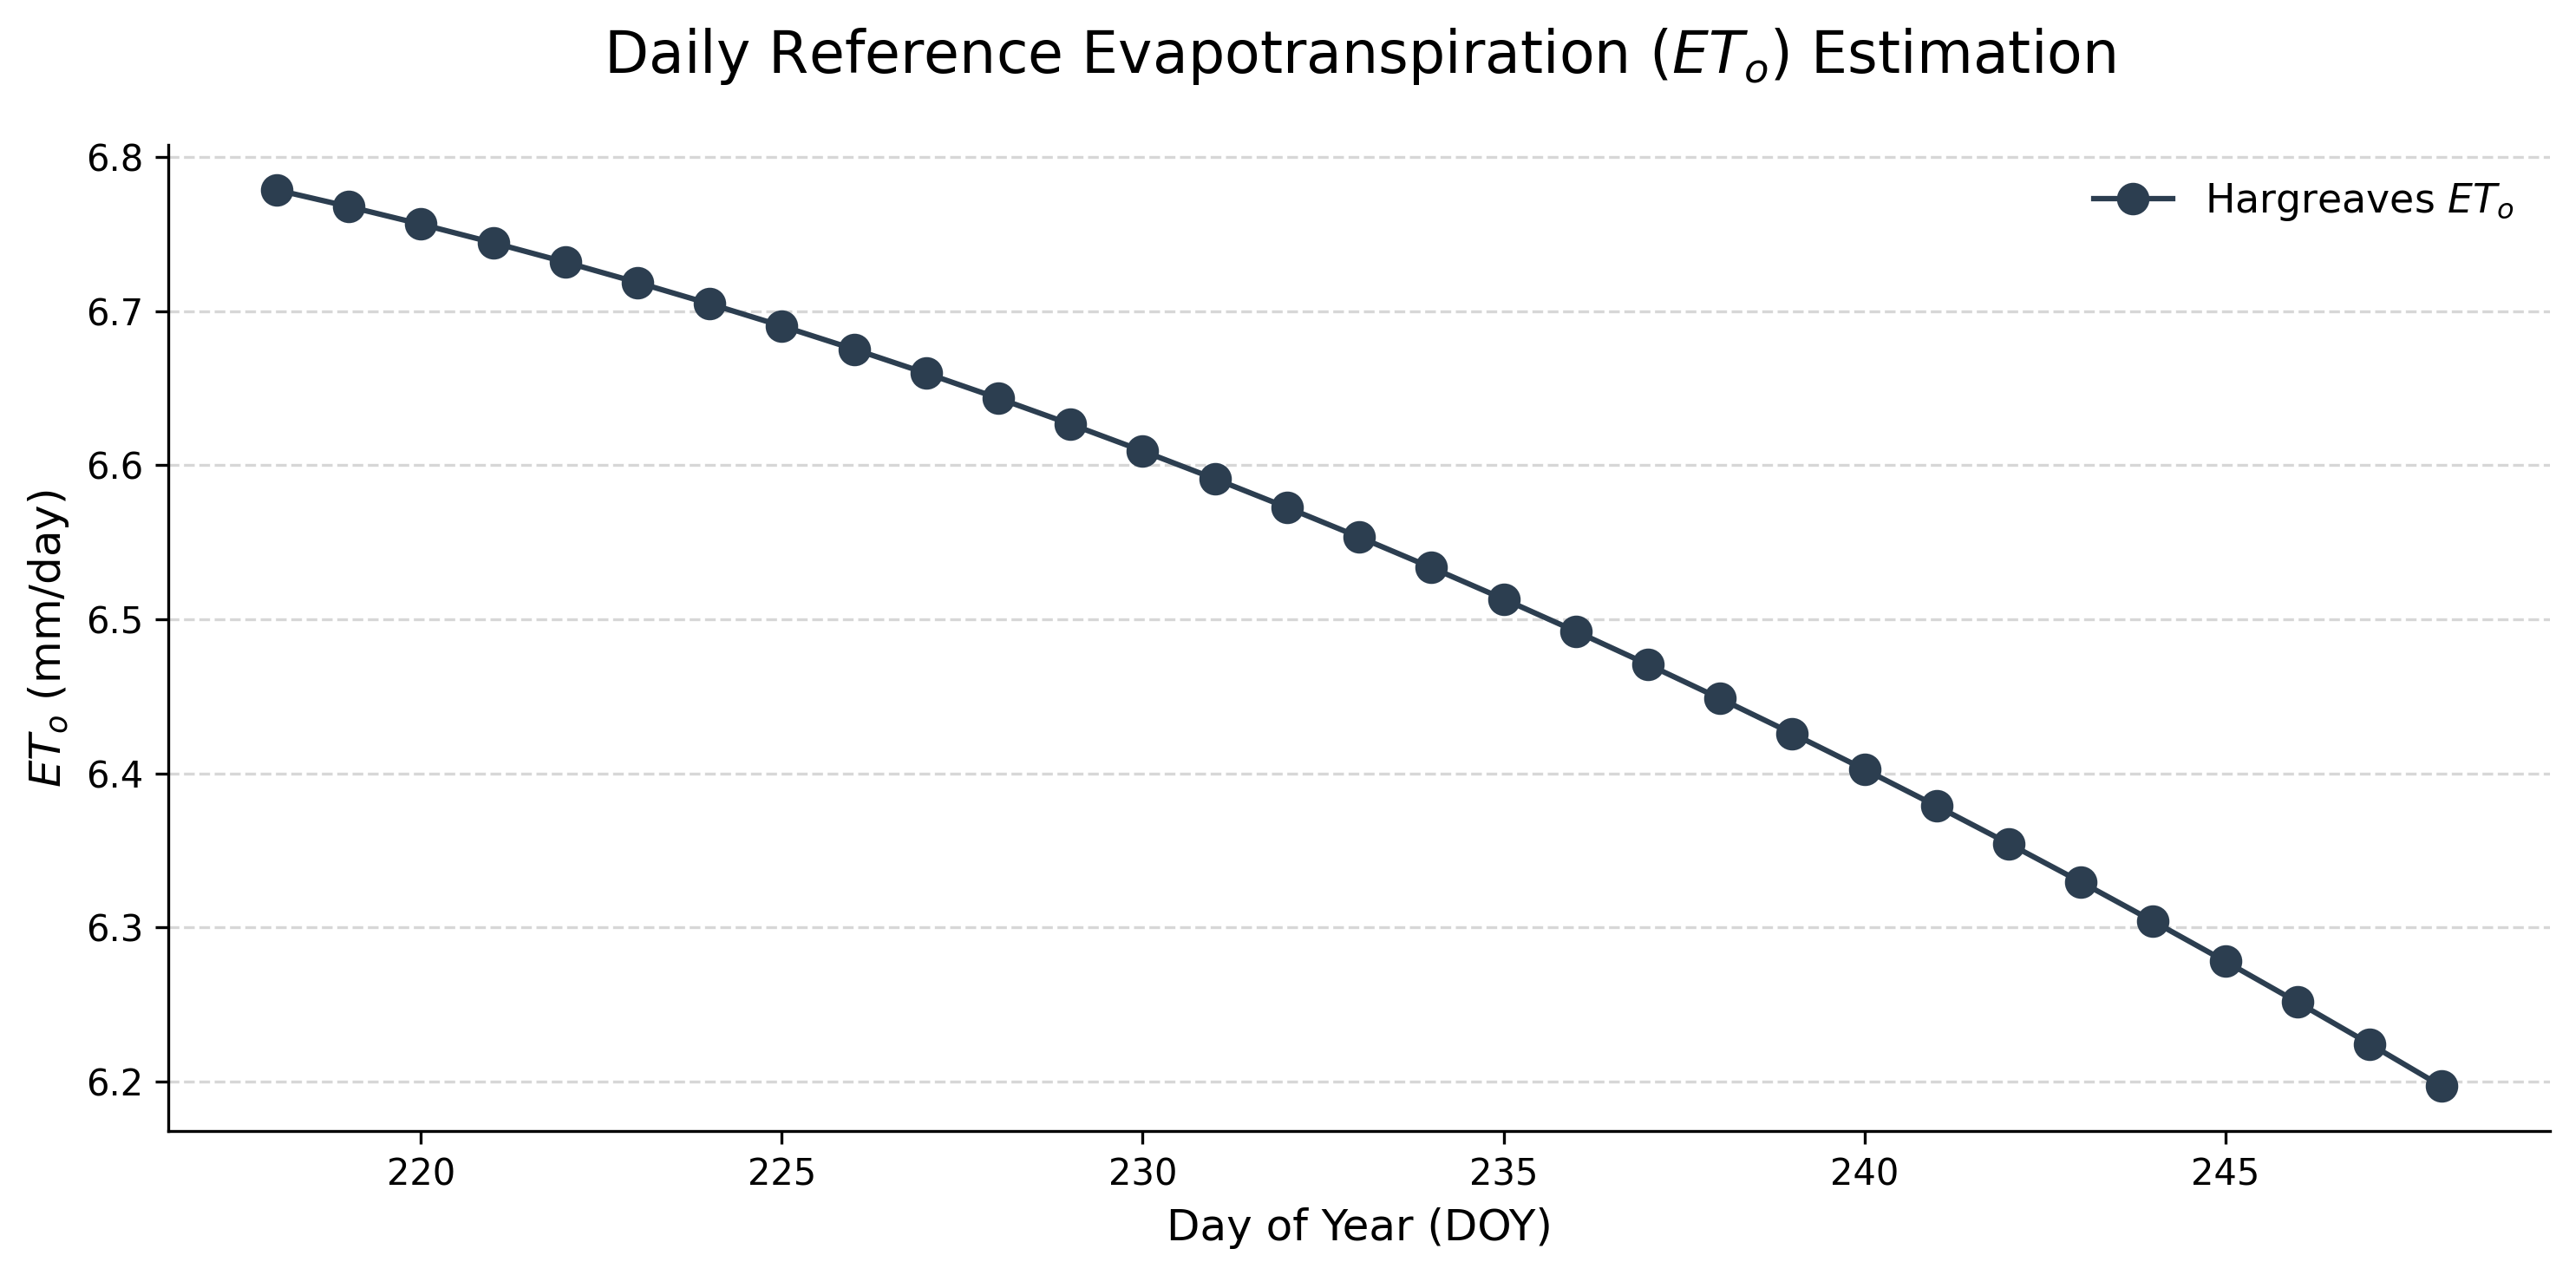

In [2]:
file_path = r"C:\GitHub\py-eto\examples\data\sample_weather.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

df['ETo_Hargreaves'] = py_eto.hargreaves(
    t_min=df['Tmin'],
    t_max=df['Tmax'],
    latitude=df['Latitude'],
    doy=df['DOY'],
    year=2025
)
print("Hargreaves ETo (mm/day):")
print(df[['DOY', 'Tmax', 'Tmin', 'Latitude', 'ETo_Hargreaves']].head())

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
ax.plot(df['DOY'], df['ETo_Hargreaves'], 
        marker='o', 
        markersize=8,
        linestyle='-', 
        color='#2c3e50', 
        linewidth=1.5, 
        label='Hargreaves $ET_o$')

ax.set_title('Daily Reference Evapotranspiration ($ET_o$) Estimation', 
             fontsize=16, pad=20)
ax.set_xlabel('Day of Year (DOY)', fontsize=12)
ax.set_ylabel('$ET_o$ (mm/day)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(frameon=False, fontsize=11)
plt.tight_layout()
plt.show()

## PM daily

In [7]:
file_path = r"C:\GitHub\py-eto\examples\data\sample_weather.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet2')
display(df.head())

,Year,DOY,Latitude,Elevation,Tmax,Tmin,RH_max,RH_min,u2,T,RH,G
0,2025,218,37.365886,65,38.3,23.4,71.3,25.3,1.5,29.8,46.3,0
1,2025,219,37.365886,65,38.4,23.5,71.2,25.2,1.7,29.9,46.2,0
2,2025,220,37.365886,65,38.5,23.6,71.1,25.1,1.3,30.0,46.1,0
3,2025,221,37.365886,65,38.6,23.7,71.0,25.0,2.1,30.1,46.0,0
4,2025,222,37.365886,65,38.7,23.8,70.9,24.9,1.1,30.2,45.9,0


In [ ]:
# from py_eto import helpers.calc_ra


file_path = r"C:\GitHub\py-eto\examples\data\sample_weather.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')
display(df.head())

df['ETo_PM'] = py_eto.pm_daily(
    t_mean=df['T'], 
    u2=df['u2'], 
    rn=df['Rn'],
    g=df['G'], 
    es=calc_es_ea(df['T'], df['RH'])[0], 
    ea=calc_es_ea(df['T'], df['RH'])[1],
    delta=calc_delta(df['T']),
    gamma=calc_gamma(calc_pressure(df['Elevation']), t_mean=df['T']),
    reference='short',
)

SyntaxError: invalid syntax (3758488168.py, line 1)